In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from optic.models.tx import pamTransmitter
from optic.models.devices import photodiode, edfa, dac, adc, mzm, basicLaserModel
from optic.dsp.equalization import dfe, ffe
from optic.models.channels import linearFiberChannel, awgn
from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc, theoryBER
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate ,signalPower
from optic.utils import parameters, dBm2W, lin2dB
from optic.plot import eyediagram, pconst
from scipy.special import erfc
import optic.comm.modulation as mod
from numpy.random import normal
import pandas as pd
import sys
import os


sys.path.append(os.path.abspath(os.path.join('..')))

In [19]:
from AnalyticalSNR import (
    superGauss,
    SNR_Folding,
    SNR_DFE,
    SNR_FFE,
    calc_S_th,
    calc_S_th_opticompy,
    calc_S_shot,
    calc_S_shot_opticompy,
    calc_S_RIN,
    calc_S_RIN_opticompy,
    calc_S_ADC,
    calc_S_ADC_opticompy,
    calc_S_N,
    calculate_oma_outer,
    get_spectral_snr,
    ber_from_snr_m_pam
)

Iniciando varredura analítica. Isso pode levar alguns segundos...


C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_7132\1241951406.py:71: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_7132\1241951406.py:94: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)


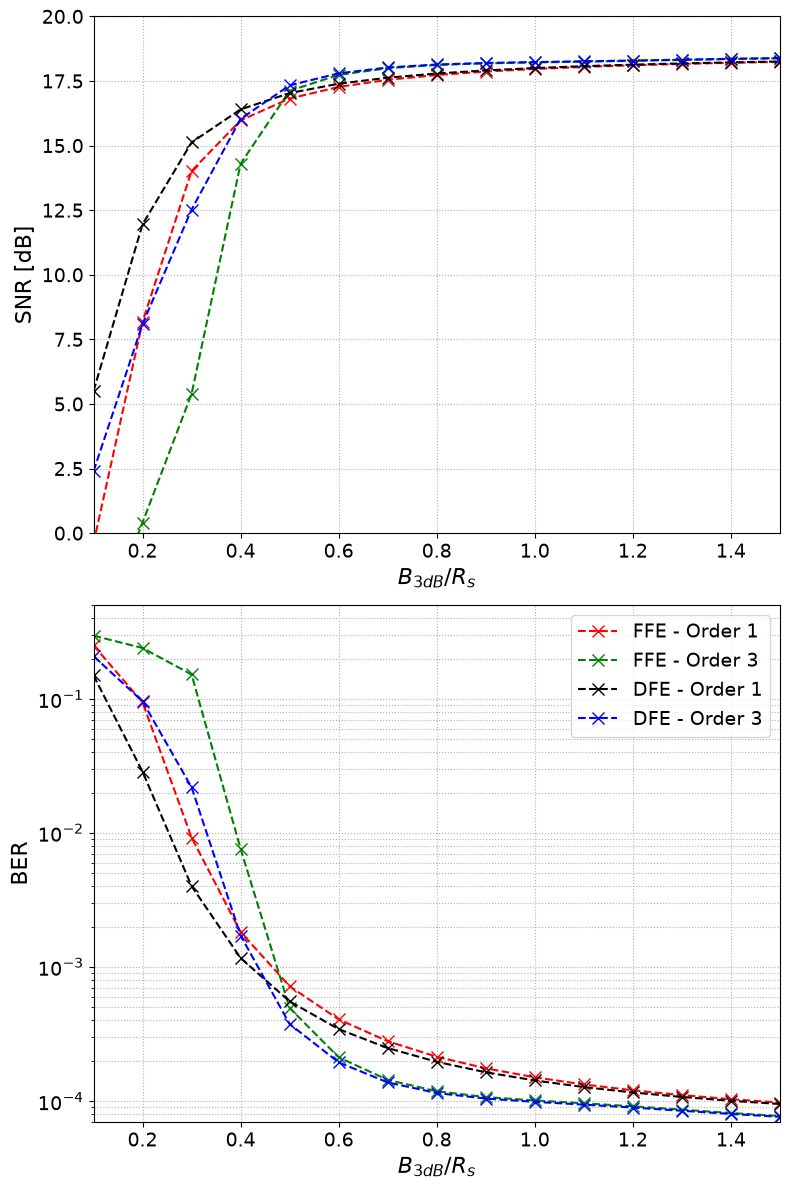

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. PARÂMETROS GLOBAIS E CONSTANTES
# =================================================================
Rs = 25e9
pTx_dBm = 0
pTx_W = 10**(pTx_dBm/10) * 1e-3
ER = 10**(6/10)
R = 1.0
N0 = 2e-19
RIN = -140
M = 4
Tb = 1 / (Rs * 2)
TX_Ts = 1 / Rs

SIM_N = 10000        
SIM_fmax = 3e12      

# Eixos de frequência
f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)

# Cálculo da OMA e Níveis do PAM-4
OMA_outer = 2 * pTx_W * ((ER - 1) / (ER + 1))
niveis_pam = np.linspace(-1, 1, M)
Ps2 = pTx_W + niveis_pam * (OMA_outer / 2)
pTx_mean_squared = np.mean(Ps2**2)

# Resposta do Pulso e Ruídos Fixos (Não dependem do filtro do canal)
Pulse = np.sinc(2 * Tb * f)
S_th = calc_S_th(N0, f)
S_shot = calc_S_shot(pTx_W, R, 1, 1, f) # Assumindo PIN sem ganho extra

# =================================================================
# 2. PREPARAÇÃO DOS LOOPS (VARREDURA)
# =================================================================
b_rs_ratios = np.arange(0.1, 1.6, 0.1) # Vai de 0.1 até 1.5
orders = [1, 3]

# Dicionários para armazenar os resultados para cada ordem
results = {
    1: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []},
    3: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []}
}

print("Iniciando varredura analítica. Isso pode levar alguns segundos...")

# =================================================================
# 3. LOOP PRINCIPAL
# =================================================================
for n in orders:
    for ratio in b_rs_ratios:
        B_3dB = ratio * Rs
        
        # 1. Resposta do Canal
        H_ch = superGauss(f, n=n, B_3dB=B_3dB)
        H_ch_sq = np.abs(H_ch)**2
        
        # 2. Ruído Total Global (Para plotar a curva de SNR Global)
        S_RIN_global = calc_S_RIN(pTx_mean_squared, RIN, f)
        S_N_total = calc_S_N(S_RIN_global, S_shot, S_th, H_ch_sq)
        
        # 3. SNR Espectral (Global)
        S_N_f = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_total)
        S_N_f = np.nan_to_num(S_N_f, nan=0.0)
        
        # 4. Folding e Integrais Globais (Para o Gráfico de SNR)
        SNR_folded = SNR_Folding(S_N_f, f, mu=2, Rs=Rs)
        SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        results[n]['snr_ffe'].append(10 * np.log10(snr_ffe_lin))
        results[n]['snr_dfe'].append(10 * np.log10(snr_dfe_lin))
        
        # 5. Loop Heurístico "Olho-por-Olho" (Para o Gráfico de BER)
        ber_ffe_eyes = []
        ber_dfe_eyes = []
        
        for i in range(M - 1):
            # Recalcula o RIN focado na potência dos 2 níveis que formam ESTE olho
            pTx_eye_squared = np.mean(Ps2[i : i+2]**2)
            S_RIN_eye = calc_S_RIN(pTx_eye_squared, RIN, f)
            S_N_eye = calc_S_N(S_RIN_eye, S_shot, S_th, H_ch_sq)
            
            # SNR e Folding deste olho
            S_N_f_eye = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_eye)
            S_N_f_eye = np.nan_to_num(S_N_f_eye, nan=0.0)
            
            SNR_folded_eye = SNR_Folding(S_N_f_eye, f, mu=2, Rs=Rs)
            SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)
            
            # Equalizadores
            snr_ffe_eye_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp_eye + 1), x=f_int)) - 1
            snr_dfe_eye_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp_eye + 1), x=f_int)) - 1
            
            ber_ffe_eyes.append(ber_from_snr_m_pam(snr_ffe_eye_lin, M))
            ber_dfe_eyes.append(ber_from_snr_m_pam(snr_dfe_eye_lin, M))
            
        # A BER final é a média das BERs dos 3 olhos
        results[n]['ber_ffe'].append(np.mean(ber_ffe_eyes))
        results[n]['ber_dfe'].append(np.mean(ber_dfe_eyes))

# =================================================================
# 4. PLOTAGEM DOS GRÁFICOS (Idêntico ao Artigo)
# =================================================================
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

# Gráfico 1: SNR
axs[0].plot(b_rs_ratios, results[1]['snr_ffe'], 'r--x', label='FFE - Order 1', markersize=8)
axs[0].plot(b_rs_ratios, results[3]['snr_ffe'], 'g--x', label='FFE - Order 3', markersize=8)
axs[0].plot(b_rs_ratios, results[1]['snr_dfe'], 'k--x', label='DFE - Order 1', markersize=8)
axs[0].plot(b_rs_ratios, results[3]['snr_dfe'], 'b--x', label='DFE - Order 3', markersize=8)
axs[0].set_xlabel(r'$B_{3dB}/R_s$', fontsize=16)
axs[0].set_ylabel('SNR [dB]', fontsize=16)
axs[0].set_ylim(0, 20)
axs[0].set_xlim(0.1, 1.5)
axs[0].grid(True, linestyle=':')
axs[0].tick_params(axis='both', labelsize=14)

# Gráfico 2: BER
axs[1].semilogy(b_rs_ratios, results[1]['ber_ffe'], 'r--x', label='FFE - Order 1', markersize=8)
axs[1].semilogy(b_rs_ratios, results[3]['ber_ffe'], 'g--x', label='FFE - Order 3', markersize=8)
axs[1].semilogy(b_rs_ratios, results[1]['ber_dfe'], 'k--x', label='DFE - Order 1', markersize=8)
axs[1].semilogy(b_rs_ratios, results[3]['ber_dfe'], 'b--x', label='DFE - Order 3', markersize=8)
axs[1].set_xlabel(r'$B_{3dB}/R_s$', fontsize=16)
axs[1].set_ylabel('BER', fontsize=16)
axs[1].set_ylim(7e-5, 0.5)
axs[1].set_xlim(0.1, 1.5)
axs[1].grid(True, linestyle=':', which='both')
axs[1].tick_params(axis='both', labelsize=14)
axs[1].legend(fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()

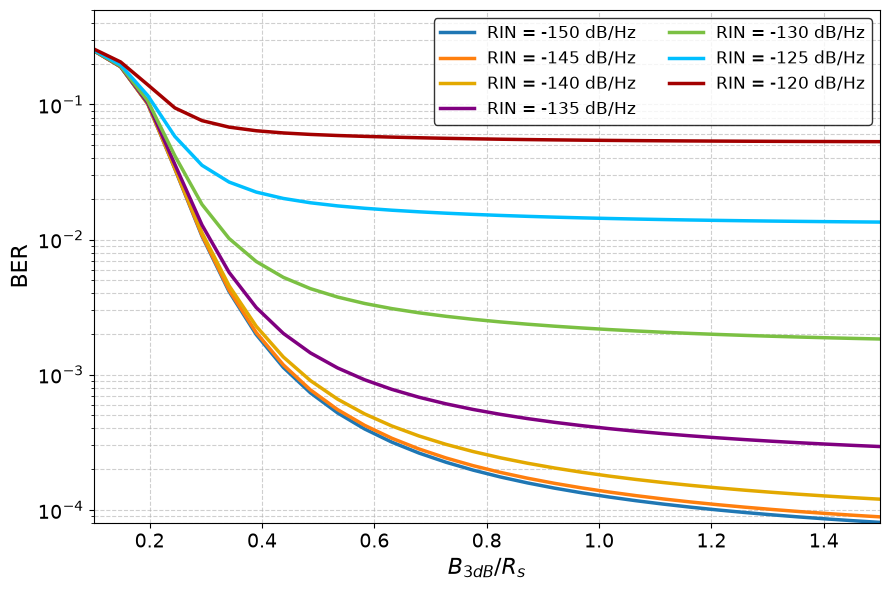

In [21]:

q = 1.602176634e-19 # Carga do elétron

# --- Parâmetros da Figura 4(b) do artigo ---
Rs = 56e9             # Taxa de símbolos: 56 GBaud
P_TX_dBm = 0          # Potência de transmissão: 0 dBm
P_TX_W = 1e-3         # Potência em Watts (1 mW)
ER_dB = 12            # Razão de extinção: 12 dB
N0 = 2e-19            # Ruído térmico [W^2/Hz] (Tabela I)
R_resp = 1.0          # Responsividade [A/W] (Tabela I)
M = 4                 # 4-PAM
n_sg = 1              # Filtro Supergaussiano de ordem 1
mu = 2                # Número de dobramentos do espectro (aliasing)

# Eixo X e variação do RIN
ratio_B_Rs = np.linspace(0.1, 1.5, 30)
RIN_list = [-150, -145, -140, -135, -130, -125, -120]

# Vetor de frequências (Banda larga o suficiente para capturar o ruído antes do folding)
f = np.linspace(-4 * Rs, 4 * Rs, 4096)
df = f[1] - f[0]

# Filtro de formatação do pulso do transmissor (Retangular no tempo -> Sinc na frequência)
# np.sinc(x) em Python calcula sin(pi*x)/(pi*x)
H_T = np.sinc(f / Rs)

# --- Cálculo dos Níveis de Potência (Heurística do Artigo) ---
# Encontrar as potências exatas dos 4 níveis do PAM para isolar os 3 olhos
ER_lin = 10**(ER_dB / 10)
P0_W = (2 * P_TX_W) / (ER_lin + 1)
P3_W = P0_W * ER_lin
OMA_W = P3_W - P0_W

# Os 4 níveis do PAM
P1_W = P0_W + OMA_W / 3
P2_W = P0_W + 2 * OMA_W / 3

# Potência Média de cada um dos 3 olhos internos
P_eye_1 = (P0_W + P1_W) / 2
P_eye_2 = (P1_W + P2_W) / 2
P_eye_3 = (P2_W + P3_W) / 2
P_eyes = [P_eye_1, P_eye_2, P_eye_3]

# Dicionário para guardar as BERs
ber_results = {rin: [] for rin in RIN_list}

# --- Loop Principal de Cálculo Analítico ---
for rin in RIN_list:
    for ratio in ratio_B_Rs:
        B_3dB = ratio * Rs
        H_ch = superGauss(f, n_sg, B_3dB)
        H_ch_sq = np.abs(H_ch)**2
        
        ber_eyes_temp = []
        
        # Iterar sobre cada olho aplicando ruídos independentes baseados em suas potências
        for P_eye in P_eyes:
            # Densidades espectrais de ruído
            S_th = np.full_like(f, N0 / 2)
            # Shot noise (G=1, F=1 para fotodiodo PIN)
            S_shot = np.full_like(f, q * P_eye * R_resp)
            # RIN
            RIN_lin = 10**(rin / 10)
            S_RIN_scalar = (RIN_lin / 2) * (P_eye**2)
            
            # Ruído total
            S_N = calc_S_N(S_RIN_scalar, S_shot, S_th, H_ch_sq)
            
            # Calcular SNR Espectral
            # OMA é passado em Watts para manter a consistência matemática com S_N em W^2/Hz
            snr_f = get_spectral_snr(f, OMA_W, Rs, H_T, H_ch, S_N)
            
            # Dobramento de espectro (Aliasing do ADC)
            snr_folded = SNR_Folding(snr_f, f, mu, Rs)
            
            # Integração analítica FFE
            snr_ffe = SNR_FFE(snr_folded, f, Rs)
            
            # Estimar BER para este olho específico
            ber_eye = ber_from_snr_m_pam(snr_ffe, M)
            ber_eyes_temp.append(ber_eye)
            
        # A BER global é a média das BERs dos 3 olhos (Equação da Seção II do artigo)
        avg_ber = np.mean(ber_eyes_temp)
        ber_results[rin].append(avg_ber)

# --- Plotagem do Gráfico ---
plt.figure(figsize=(9, 6))

# Paleta de cores para se assemelhar com as curvas do artigo
colors = ['#1f77b4', '#ff7f0e', '#e3a900', '#800080', '#7bc043', '#00bfff', '#a30000']

for i, rin in enumerate(RIN_list):
    plt.semilogy(ratio_B_Rs, ber_results[rin], label=f'RIN = {rin} dB/Hz', 
                 color=colors[i], linewidth=2.5)

plt.xlabel(r'$B_{3dB}/R_s$', fontsize=16)
plt.ylabel('BER', fontsize=16)

# Configurações para idêntica visualização do artigo
plt.ylim(8e-5, 5e-1)
plt.xlim(0.1, 1.5)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(ncol=2, fontsize=12, loc='upper right', edgecolor='black')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()

plt.show()

Gerando sinal transmitido para a simulação...
Iniciando varredura conjunta (Analítica + Simulação)...
Processando Ordem=1, B_3dB/Rs=0.1...


C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_7132\3311265580.py:99: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_7132\3311265580.py:117: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)


Processando Ordem=1, B_3dB/Rs=0.2...


C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_7132\3311265580.py:99: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
C:\Users\T-GAMER\AppData\Local\Temp\ipykernel_7132\3311265580.py:117: RuntimeWarning: divide by zero encountered in log10
  SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)


Processando Ordem=1, B_3dB/Rs=0.3...
Processando Ordem=1, B_3dB/Rs=0.4...
Processando Ordem=1, B_3dB/Rs=0.5...
Processando Ordem=1, B_3dB/Rs=0.6...
Processando Ordem=1, B_3dB/Rs=0.7...
Processando Ordem=1, B_3dB/Rs=0.8...
Processando Ordem=1, B_3dB/Rs=0.9...
Processando Ordem=1, B_3dB/Rs=1.0...
Processando Ordem=1, B_3dB/Rs=1.1...
Processando Ordem=1, B_3dB/Rs=1.2...
Processando Ordem=1, B_3dB/Rs=1.3...
Processando Ordem=1, B_3dB/Rs=1.4...
Processando Ordem=1, B_3dB/Rs=1.5...
Processando Ordem=3, B_3dB/Rs=0.1...
Processando Ordem=3, B_3dB/Rs=0.2...
Processando Ordem=3, B_3dB/Rs=0.3...
Processando Ordem=3, B_3dB/Rs=0.4...
Processando Ordem=3, B_3dB/Rs=0.5...
Processando Ordem=3, B_3dB/Rs=0.6...
Processando Ordem=3, B_3dB/Rs=0.7...
Processando Ordem=3, B_3dB/Rs=0.8...
Processando Ordem=3, B_3dB/Rs=0.9...
Processando Ordem=3, B_3dB/Rs=1.0...
Processando Ordem=3, B_3dB/Rs=1.1...
Processando Ordem=3, B_3dB/Rs=1.2...
Processando Ordem=3, B_3dB/Rs=1.3...
Processando Ordem=3, B_3dB/Rs=1.4...
P

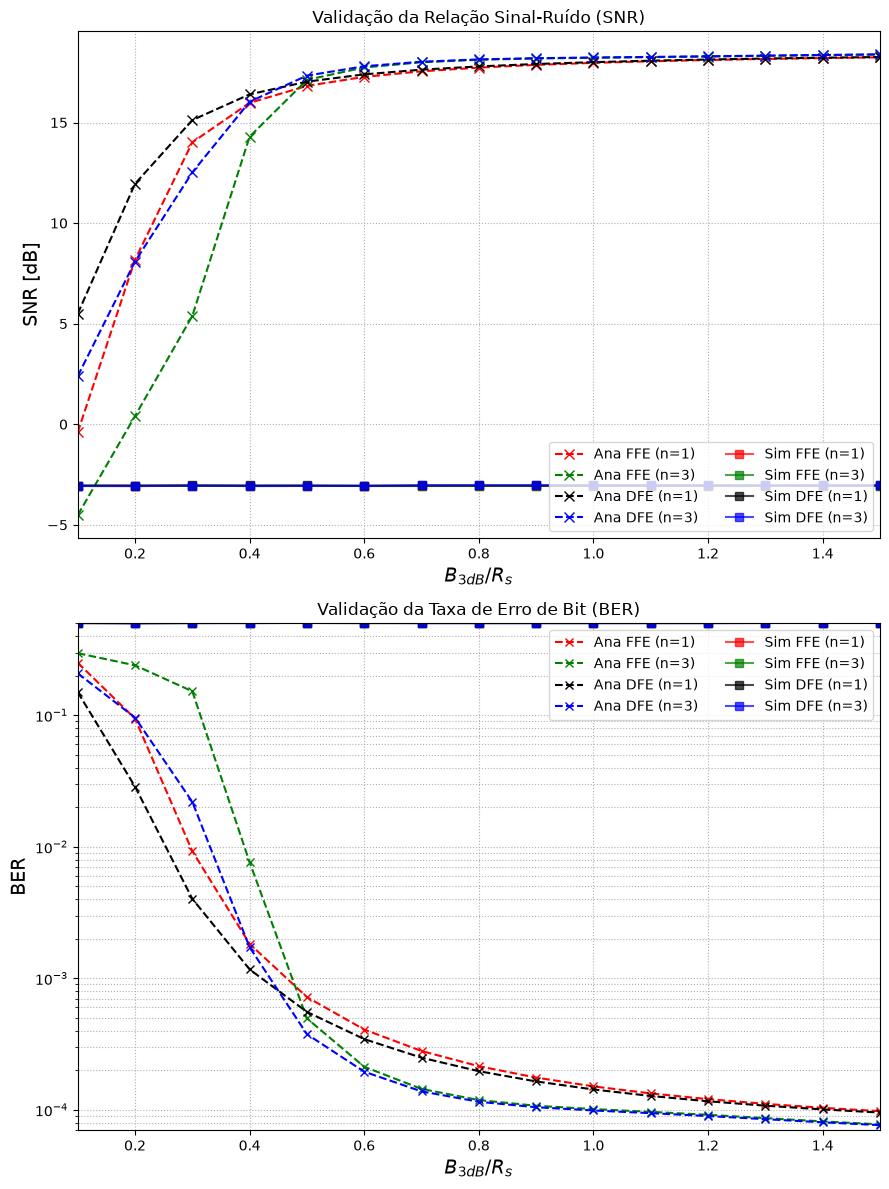

In [22]:

# (Assumindo que suas funções analíticas calc_S_RIN, calc_S_N_temp, SNR_Folding, etc., estão definidas aqui)

# =================================================================
# 1. PARÂMETROS GLOBAIS E CONSTANTES
# =================================================================
Rs = 25e9
SpS = 8
Fs = Rs * SpS
M = 4

pTx_dBm = 0
pTx_W = 10**(pTx_dBm/10) * 1e-3
ER = 10**(6/10)
R = 1.0
N0 = 2e-19
RIN = -140
Tb = 1 / (Rs * 2)
TX_Ts = 1 / Rs

# Eixos de frequência (Analítico)
SIM_N = 10000        
SIM_fmax = 3e12      
f = np.linspace(-SIM_fmax, SIM_fmax, SIM_N + 1)
f_int = np.linspace(-1 / (2 * TX_Ts), 1 / (2 * TX_Ts), SIM_N)

# Cálculo da OMA e Níveis do PAM-4
OMA_outer = 2 * pTx_W * ((ER - 1) / (ER + 1))
niveis_pam = np.linspace(-1, 1, M)
Ps2 = pTx_W + niveis_pam * (OMA_outer / 2)
pTx_mean_squared = np.mean(Ps2**2)
P0 = pTx_W - OMA_outer/2

# Resposta do Pulso e Ruídos Fixos (Analítico)
Pulse = np.sinc(2 * Tb * f)
S_th = calc_S_th(N0, f)
S_shot = calc_S_shot(pTx_W, R, 1, 1, f)

# =================================================================
# 2. PREPARAÇÃO DA SIMULAÇÃO TEMPORAL (FORA DO LOOP PARA VELOCIDADE)
# =================================================================
print("Gerando sinal transmitido para a simulação...")
paramBits = parameters()
paramBits.nBits = int(80000 * np.log2(M)) # Reduzido levemente para acelerar o loop duplo
paramBits.mode = 'random'
paramBits.seed = 123
bitsTx = bitSource(paramBits)

symbTx_norm = modulateGray(bitsTx, M, 'pam')
symbTx_norm = pnorm(symbTx_norm) 

levels_norm = np.unique(symbTx_norm)
levels_watt = [P0, P0 + OMA_outer/3, P0 + 2*OMA_outer/3, P0 + OMA_outer]
symbTx_W = np.zeros_like(symbTx_norm, dtype=float)
for i in range(M):
    symbTx_W[symbTx_norm == levels_norm[i]] = levels_watt[i]

symbolsUp = upsample(symbTx_W, SpS)
paramPulse = parameters()
paramPulse.pulseType = 'nrz'
paramPulse.SpS = SpS
pulse = pulseShape(paramPulse)
sigTx_W = firFilter(pulse, symbolsUp)

# =================================================================
# 3. PREPARAÇÃO DOS LOOPS (VARREDURA)
# =================================================================
b_rs_ratios = np.arange(0.1, 1.6, 0.1)
orders = [1, 3]

results_ana = {1: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []},
               3: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []}}

results_sim = {1: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []},
               3: {'snr_ffe': [], 'snr_dfe': [], 'ber_ffe': [], 'ber_dfe': []}}

print("Iniciando varredura conjunta (Analítica + Simulação)...")

# =================================================================
# 4. LOOP PRINCIPAL
# =================================================================
for n in orders:
    for ratio in b_rs_ratios:
        B_3dB = ratio * Rs
        print(f"Processando Ordem={n}, B_3dB/Rs={ratio:.1f}...")
        
        # ---------------------------------------------------------
        # PARTE A: MODELO ANALÍTICO
        # ---------------------------------------------------------
        H_ch = superGauss(f, n=n, B_3dB=B_3dB)
        H_ch_sq = np.abs(H_ch)**2
        
        S_RIN_global = calc_S_RIN(pTx_mean_squared, RIN, f)
        S_N_total = calc_S_N(S_RIN_global, S_shot, S_th, H_ch_sq)
        
        S_N_f = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_total)
        S_N_f = np.nan_to_num(S_N_f, nan=0.0)
        
        SNR_folded = SNR_Folding(S_N_f, f, mu=2, Rs=Rs)
        SNR_f_interp = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded))) / 10)
        
        snr_ffe_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp + 1), x=f_int)) - 1
        snr_dfe_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp + 1), x=f_int)) - 1
        
        results_ana[n]['snr_ffe'].append(10 * np.log10(snr_ffe_lin))
        results_ana[n]['snr_dfe'].append(10 * np.log10(snr_dfe_lin))
        
        ber_ffe_eyes, ber_dfe_eyes = [], []
        for i in range(M - 1):
            pTx_eye_squared = np.mean(Ps2[i : i+2]**2)
            S_RIN_eye = calc_S_RIN(pTx_eye_squared, RIN, f)
            S_N_eye = calc_S_N(S_RIN_eye, S_shot, S_th, H_ch_sq)
            
            S_N_f_eye = get_spectral_snr(f, OMA_outer, Rs, Pulse, H_ch, S_N_eye)
            S_N_f_eye = np.nan_to_num(S_N_f_eye, nan=0.0)
            
            SNR_folded_eye = SNR_Folding(S_N_f_eye, f, mu=2, Rs=Rs)
            SNR_f_interp_eye = 10**(np.interp(f_int, f, 10 * np.log10(np.abs(SNR_folded_eye))) / 10)
            
            snr_ffe_eye_lin = 1 / (TX_Ts * np.trapezoid(1 / (SNR_f_interp_eye + 1), x=f_int)) - 1
            snr_dfe_eye_lin = np.exp(TX_Ts * np.trapezoid(np.log(SNR_f_interp_eye + 1), x=f_int)) - 1
            
            ber_ffe_eyes.append(ber_from_snr_m_pam(snr_ffe_eye_lin, M))
            ber_dfe_eyes.append(ber_from_snr_m_pam(snr_dfe_eye_lin, M))
            
        results_ana[n]['ber_ffe'].append(np.mean(ber_ffe_eyes))
        results_ana[n]['ber_dfe'].append(np.mean(ber_dfe_eyes))

        # ---------------------------------------------------------
        # PARTE B: SIMULAÇÃO TEMPORAL
        # ---------------------------------------------------------
        # Adição do RIN
        rin_lin = 10**(RIN / 10)
        var_rin = rin_lin * (sigTx_W**2) * (Fs / 2)
        n_rin = np.random.normal(0, np.sqrt(np.maximum(var_rin, 0)))
        sigTx_rin = sigTx_W + n_rin

        # Filtro H_ch
        f_sim = fftfreq(len(sigTx_rin), 1/Fs)
        H_ch_sim = np.exp(-(np.log(2)/2) * (f_sim / B_3dB)**(2*n))
        sigCh = np.real(ifft(fft(sigTx_rin) * H_ch_sim))
        sigCh_opt = np.maximum(sigCh, 0) 

        # Fotodiodo
        paramPD = parameters()
        paramPD.R = 1.0
        paramPD.ideal = False
        paramPD.shotNoise = True
        paramPD.thermalNoise = True
        paramPD.B = Fs / 2 
        paramPD.Fs = Fs
        paramPD.seed = 456
        I_Rx = photodiode(sigCh_opt, paramPD)

        # Preparação do Sinal (Remoção DC e Normalização)
        I_Rx_ac = I_Rx - np.mean(I_Rx)
        I_Rx_norm = pnorm(I_Rx_ac)

        nTrain = 60000 
        discard = nTrain

        # FFE
        paramFFE = parameters()
        paramFFE.nTaps = 51 # Reduzido para agilizar varredura
        paramFFE.mu = 1e-3
        paramFFE.nTrain = nTrain
        paramFFE.SpS = SpS
        paramFFE.M = M
        paramFFE.trainingMode = "fulltime"
        outFFE, _, _ = ffe(I_Rx_norm, symbTx_norm, paramFFE)

        # DFE
        paramDFE = parameters()
        paramDFE.nTapsFF = 51
        paramDFE.nTapsFB = 15
        paramDFE.SpS = SpS
        paramDFE.mu = 1e-3
        paramDFE.nTrain = nTrain
        paramDFE.M = M
        paramDFE.trainingMode = "fulltime"
        outDFE, _, _, _ = dfe(I_Rx_norm, symbTx_norm, paramDFE)

        # Cálculo de Desempenho
        dec_ffe = len(outFFE) // len(symbTx_norm)
        dec_dfe = len(outDFE) // len(symbTx_norm)
        
        outFFE_1sps = outFFE[::dec_ffe]
        outDFE_1sps = outDFE[::dec_dfe]
        
        min_len_ffe = min(len(outFFE_1sps), len(symbTx_norm))
        min_len_dfe = min(len(outDFE_1sps), len(symbTx_norm))
        
        ber_sim_ffe, _, snr_sim_ffe = fastBERcalc(
            outFFE_1sps[discard : min_len_ffe - discard//10], 
            symbTx_norm[discard : min_len_ffe - discard//10], M, 'pam')
            
        ber_sim_dfe, _, snr_sim_dfe = fastBERcalc(
            outDFE_1sps[discard : min_len_dfe - discard//10], 
            symbTx_norm[discard : min_len_dfe - discard//10], M, 'pam')
            
        results_sim[n]['snr_ffe'].append(snr_sim_ffe[0])
        results_sim[n]['snr_dfe'].append(snr_sim_dfe[0])
        results_sim[n]['ber_ffe'].append(ber_sim_ffe[0])
        results_sim[n]['ber_dfe'].append(ber_sim_dfe[0])

# =================================================================
# 5. PLOTAGEM DOS GRÁFICOS (Analítico vs Simulação)
# =================================================================
fig, axs = plt.subplots(2, 1, figsize=(9, 12))

# Gráfico 1: SNR
axs[0].plot(b_rs_ratios, results_ana[1]['snr_ffe'], 'r--x', label='Ana FFE (n=1)', markersize=7)
axs[0].plot(b_rs_ratios, results_ana[3]['snr_ffe'], 'g--x', label='Ana FFE (n=3)', markersize=7)
axs[0].plot(b_rs_ratios, results_ana[1]['snr_dfe'], 'k--x', label='Ana DFE (n=1)', markersize=7)
axs[0].plot(b_rs_ratios, results_ana[3]['snr_dfe'], 'b--x', label='Ana DFE (n=3)', markersize=7)

axs[0].plot(b_rs_ratios, results_sim[1]['snr_ffe'], 'r-s', label='Sim FFE (n=1)', alpha=0.7)
axs[0].plot(b_rs_ratios, results_sim[3]['snr_ffe'], 'g-s', label='Sim FFE (n=3)', alpha=0.7)
axs[0].plot(b_rs_ratios, results_sim[1]['snr_dfe'], 'k-s', label='Sim DFE (n=1)', alpha=0.7)
axs[0].plot(b_rs_ratios, results_sim[3]['snr_dfe'], 'b-s', label='Sim DFE (n=3)', alpha=0.7)

axs[0].set_xlabel(r'$B_{3dB}/R_s$', fontsize=14)
axs[0].set_ylabel('SNR [dB]', fontsize=14)
axs[0].set_xlim(0.1, 1.5)
axs[0].grid(True, linestyle=':')
axs[0].legend(ncol=2, fontsize=10, loc='lower right')
axs[0].set_title('Validação da Relação Sinal-Ruído (SNR)')

# Gráfico 2: BER
axs[1].semilogy(b_rs_ratios, results_ana[1]['ber_ffe'], 'r--x', label='Ana FFE (n=1)')
axs[1].semilogy(b_rs_ratios, results_ana[3]['ber_ffe'], 'g--x', label='Ana FFE (n=3)')
axs[1].semilogy(b_rs_ratios, results_ana[1]['ber_dfe'], 'k--x', label='Ana DFE (n=1)')
axs[1].semilogy(b_rs_ratios, results_ana[3]['ber_dfe'], 'b--x', label='Ana DFE (n=3)')

axs[1].semilogy(b_rs_ratios, results_sim[1]['ber_ffe'], 'r-s', label='Sim FFE (n=1)', alpha=0.7)
axs[1].semilogy(b_rs_ratios, results_sim[3]['ber_ffe'], 'g-s', label='Sim FFE (n=3)', alpha=0.7)
axs[1].semilogy(b_rs_ratios, results_sim[1]['ber_dfe'], 'k-s', label='Sim DFE (n=1)', alpha=0.7)
axs[1].semilogy(b_rs_ratios, results_sim[3]['ber_dfe'], 'b-s', label='Sim DFE (n=3)', alpha=0.7)

axs[1].set_xlabel(r'$B_{3dB}/R_s$', fontsize=14)
axs[1].set_ylabel('BER', fontsize=14)
axs[1].set_ylim(7e-5, 0.5)
axs[1].set_xlim(0.1, 1.5)
axs[1].grid(True, linestyle=':', which='both')
axs[1].legend(ncol=2, fontsize=10, loc='upper right')
axs[1].set_title('Validação da Taxa de Erro de Bit (BER)')

plt.tight_layout()
plt.show()